In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [2]:
ruta = r'C:\Users\palom\OneDrive\Escritorio\SPOTYFY\Spotify_data_total.csv'
Spotify_limpio = pd.read_csv(ruta)
Spotify_limpio = pd.read_csv('C:/Users/palom/OneDrive/Escritorio/SPOTYFY/Spotify_data_total.csv')

In [3]:
Spotify_limpio.head()

,EDAD,GENERO,ANTIGUEDAD,DISPOSITIVO,SUSCRIPCION,QUIERE_PREMIUM,PREMIUM_PREFERIDO,CONTENIDO_PREFERIDO,GENERO_FAV_MUSICA,FRANJA_HORARIA,...,MOMENTO_MUSICA,DESCUBRIMIENTO,VALORACION_RECOMENDACIONES,FRECUENCIA_POD,GENERO_FAV_POD,FORMATO_PREFERIDO_POD,PREFERENCIA_PRESENTADOR_POD,PREFERENCIA_DURACION_POD,SATISFACCION_POD,CANTIDAD_DISPOSITIVOS
0,20-35,Mujer,Más de 2 años,Altavoz Inteligente,Free,Si,Family Plan-Rs 179/month,Podcast,Melody,Noche,...,Tiempo libre,Listas de reproducción,3,Diariamente,Comedia,Entrevista,Ambos,Ambos,Ok,1
1,12-20,Hombre,Más de 2 años,Ordenador,Free,Si,Individual Plan- Rs 119/ month,Podcast,Rap,Tarde,...,Entrenamiento,Listas de reproducción,2,Varias veces por semana,Comedia,Entrevista,Ambos,No aplicable/Ninguno,Satisfecho,1
2,35-60,Otro,De 6 meses a 1 año,Altavoz Inteligente,Free,Si,Student Plan-Rs 59/month,Podcast,Pop,Noche,...,"Horas de estudio, Mientras viaja",Listas de reproducción,4,Una vez por semana,Deportes,Entrevista,No aplicable/Ninguno,Ambos,Satisfecho,1
3,20-35,Mujer,De 1 año a 2 años,"Smartphone, Altavoz Inteligente",Free,No,No aplicable/Ninguno,Music,Melody,Noche,...,"Horario de oficina, Entrenamiento, Tiempo libre","Recomendaciones, Listas de reproducción",4,Nunca,No aplicable/Ninguno,No aplicable/Ninguno,No aplicable/Ninguno,No aplicable/Ninguno,Ok,2
4,20-35,Mujer,De 1 año a 2 años,Smartphone,Free,No,No aplicable/Ninguno,Music,Melody,Noche,...,Tiempo libre,"Recomendaciones, Listas de reproducción",4,Raramente,Estilo de vida y salud,Relato,Famoso,Ambos,Ok,1


In [4]:
Spotify_limpio.columns

Index(['EDAD', 'GENERO', 'ANTIGUEDAD', 'DISPOSITIVO', 'SUSCRIPCION',
       'QUIERE_PREMIUM', 'PREMIUM_PREFERIDO', 'CONTENIDO_PREFERIDO',
       'GENERO_FAV_MUSICA', 'FRANJA_HORARIA', 'ESTADO_ANIMO', 'MOMENTO_MUSICA',
       'DESCUBRIMIENTO', 'VALORACION_RECOMENDACIONES', 'FRECUENCIA_POD',
       'GENERO_FAV_POD', 'FORMATO_PREFERIDO_POD',
       'PREFERENCIA_PRESENTADOR_POD', 'PREFERENCIA_DURACION_POD',
       'SATISFACCION_POD', 'CANTIDAD_DISPOSITIVOS'],
      dtype='object')

In [5]:
Spotify_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   EDAD                         520 non-null    object
 1   GENERO                       520 non-null    object
 2   ANTIGUEDAD                   520 non-null    object
 3   DISPOSITIVO                  520 non-null    object
 4   SUSCRIPCION                  520 non-null    object
 5   QUIERE_PREMIUM               520 non-null    object
 6   PREMIUM_PREFERIDO            520 non-null    object
 7   CONTENIDO_PREFERIDO          520 non-null    object
 8   GENERO_FAV_MUSICA            520 non-null    object
 9   FRANJA_HORARIA               520 non-null    object
 10  ESTADO_ANIMO                 520 non-null    object
 11  MOMENTO_MUSICA               520 non-null    object
 12  DESCUBRIMIENTO               520 non-null    object
 13  VALORACION_RECOMENDACIONES   520 no

### Codificación de columnas multirrespuesta

In [6]:
multirrespuesta_cols = ["DISPOSITIVO", "MOMENTO_MUSICA", "DESCUBRIMIENTO", "ESTADO_ANIMO", "GENERO_FAV_POD"]

for col in multirrespuesta_cols:
    Spotify_limpio[col] = Spotify_limpio[col].str.split(r",\s*")

for col in multirrespuesta_cols:
    dummies = Spotify_limpio[col].str.join("|").str.get_dummies()
    dummies = dummies.add_prefix(col + "_")
    Spotify_limpio = pd.concat([Spotify_limpio, dummies], axis=1)
    Spotify_limpio.drop(columns=[col], inplace=True)

In [7]:
Spotify_limpio

,EDAD,GENERO,ANTIGUEDAD,SUSCRIPCION,QUIERE_PREMIUM,PREMIUM_PREFERIDO,CONTENIDO_PREFERIDO,GENERO_FAV_MUSICA,FRANJA_HORARIA,VALORACION_RECOMENDACIONES,...,GENERO_FAV_POD_Estilo de vida y salud,GENERO_FAV_POD_Finanzas y actualidad,GENERO_FAV_POD_Historias,GENERO_FAV_POD_Misterio y crímenes,GENERO_FAV_POD_Negocios,GENERO_FAV_POD_No aplicable/Ninguno,GENERO_FAV_POD_Novelas,GENERO_FAV_POD_Política e información (temas de interés),GENERO_FAV_POD_Salud y fitness,GENERO_FAV_POD_Tecnología
0,20-35,Mujer,Más de 2 años,Free,Si,Family Plan-Rs 179/month,Podcast,Melody,Noche,3,...,0,0,0,0,0,0,0,0,0,0
1,12-20,Hombre,Más de 2 años,Free,Si,Individual Plan- Rs 119/ month,Podcast,Rap,Tarde,2,...,0,0,0,0,0,0,0,0,0,0
2,35-60,Otro,De 6 meses a 1 año,Free,Si,Student Plan-Rs 59/month,Podcast,Pop,Noche,4,...,0,0,0,0,0,0,0,0,0,0
3,20-35,Mujer,De 1 año a 2 años,Free,No,No aplicable/Ninguno,Music,Melody,Noche,4,...,0,0,0,0,0,1,0,0,0,0
4,20-35,Mujer,De 1 año a 2 años,Free,No,No aplicable/Ninguno,Music,Melody,Noche,4,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,20-35,Mujer,Más de 2 años,Free,Si,Student Plan-Rs 59/month,Music,Pop,Mañana,5,...,1,0,0,0,0,0,0,0,0,0
516,20-35,Mujer,Más de 2 años,Free,Si,Student Plan-Rs 59/month,Music,Pop,Noche,2,...,0,0,0,0,0,0,0,0,0,0
517,20-35,Mujer,Más de 2 años,Free,No,Student Plan-Rs 59/month,Music,Pop,Noche,3,...,0,0,0,0,0,1,0,0,0,0
518,20-35,Mujer,De 6 meses a 1 año,Premium,Si,Individual Plan- Rs 119/ month,Music,Melody,Noche,2,...,0,0,0,0,0,0,0,0,0,0


### Codificación de la tabla completa

In [8]:
Spotify_codificado = pd.get_dummies(Spotify_limpio, drop_first=True)

In [9]:
Spotify_codificado.head()

,VALORACION_RECOMENDACIONES,CANTIDAD_DISPOSITIVOS,DISPOSITIVO_Altavoz Inteligente,DISPOSITIVO_Dispositivo Portatil Inteligente,DISPOSITIVO_Ordenador,DISPOSITIVO_Smartphone,MOMENTO_MUSICA_Aleatorio,MOMENTO_MUSICA_Antes de dormir,MOMENTO_MUSICA_Cocinando,MOMENTO_MUSICA_Entrenamiento,...,PREFERENCIA_PRESENTADOR_POD_Desconocido,PREFERENCIA_PRESENTADOR_POD_Famoso,PREFERENCIA_PRESENTADOR_POD_No aplicable/Ninguno,PREFERENCIA_DURACION_POD_Corto,PREFERENCIA_DURACION_POD_Largo,PREFERENCIA_DURACION_POD_No aplicable/Ninguno,SATISFACCION_POD_Muy insatisfecho,SATISFACCION_POD_Muy satisfecho,SATISFACCION_POD_Ok,SATISFACCION_POD_Satisfecho
0,3,1,1,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
1,2,1,0,0,1,0,0,0,0,1,...,False,False,False,False,False,True,False,False,False,True
2,4,1,1,0,0,0,0,0,0,0,...,False,False,True,False,False,False,False,False,False,True
3,4,2,1,0,0,1,0,0,0,1,...,False,False,True,False,False,True,False,False,True,False
4,4,1,0,0,0,1,0,0,0,0,...,False,True,False,False,False,False,False,False,True,False


In [10]:
for col in Spotify_limpio.columns:
    print(f"\n--- {col} ---")
    print(Spotify_limpio[col].value_counts())


--- EDAD ---
EDAD
20-35    422
12-20     71
35-60     23
6-12       3
60+        1
Name: count, dtype: int64

--- GENERO ---
GENERO
Mujer     391
Hombre    114
Otro       15
Name: count, dtype: int64

--- ANTIGUEDAD ---
ANTIGUEDAD
Más de 2 años         169
De 1 año a 2 años     141
De 6 meses a 1 año    119
Menos de 6 meses       91
Name: count, dtype: int64

--- SUSCRIPCION ---
SUSCRIPCION
Free       424
Premium     96
Name: count, dtype: int64

--- QUIERE_PREMIUM ---
QUIERE_PREMIUM
No    334
Si    186
Name: count, dtype: int64

--- PREMIUM_PREFERIDO ---
PREMIUM_PREFERIDO
No aplicable/Ninguno              208
Individual Plan- Rs 119/ month     95
Student Plan-Rs 59/month           94
Duo plan- Rs 149/month             84
Family Plan-Rs 179/month           39
Name: count, dtype: int64

--- CONTENIDO_PREFERIDO ---
CONTENIDO_PREFERIDO
Music      410
Podcast    110
Name: count, dtype: int64

--- GENERO_FAV_MUSICA ---
GENERO_FAV_MUSICA
Melody                       259
classical           

### Limpieza nombres + todo (0,1)

In [11]:
Spotify_codificado.columns = Spotify_codificado.columns.str.replace(' ', '_').str.replace('/', '_')

In [12]:
Spotify_codificado = Spotify_codificado.astype(int)

In [13]:
Spotify_codificado.head()

,VALORACION_RECOMENDACIONES,CANTIDAD_DISPOSITIVOS,DISPOSITIVO_Altavoz_Inteligente,DISPOSITIVO_Dispositivo_Portatil_Inteligente,DISPOSITIVO_Ordenador,DISPOSITIVO_Smartphone,MOMENTO_MUSICA_Aleatorio,MOMENTO_MUSICA_Antes_de_dormir,MOMENTO_MUSICA_Cocinando,MOMENTO_MUSICA_Entrenamiento,...,PREFERENCIA_PRESENTADOR_POD_Desconocido,PREFERENCIA_PRESENTADOR_POD_Famoso,PREFERENCIA_PRESENTADOR_POD_No_aplicable_Ninguno,PREFERENCIA_DURACION_POD_Corto,PREFERENCIA_DURACION_POD_Largo,PREFERENCIA_DURACION_POD_No_aplicable_Ninguno,SATISFACCION_POD_Muy_insatisfecho,SATISFACCION_POD_Muy_satisfecho,SATISFACCION_POD_Ok,SATISFACCION_POD_Satisfecho
0,3,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,2,1,0,0,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
2,4,1,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
3,4,2,1,0,0,1,0,0,0,1,...,0,0,1,0,0,1,0,0,1,0
4,4,1,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0


In [ ]:
¿Qué columnas influyen más?

In [14]:
correlaciones = Spotify_codificado.corr()['VALORACION_RECOMENDACIONES'].sort_values(ascending=False)
print(correlaciones.head(10))

VALORACION_RECOMENDACIONES               1.000000
DISPOSITIVO_Smartphone                   0.382179
ESTADO_ANIMO_Relajación                  0.319901
FRANJA_HORARIA_Noche                     0.279986
DESCUBRIMIENTO_Recomendaciones           0.237795
PREFERENCIA_DURACION_POD_Corto           0.186558
DESCUBRIMIENTO_Listas_de_reproducción    0.180751
GENERO_FAV_MUSICA_Melody                 0.170981
EDAD_20-35                               0.157664
SATISFACCION_POD_Muy_satisfecho          0.148102
Name: VALORACION_RECOMENDACIONES, dtype: float64


In [ ]:
Me quedo solo con los usuarios premium

In [16]:
df_premium = Spotify_codificado[Spotify_codificado['SUSCRIPCION_Premium'] == 1].copy()
df_premium.head()

,VALORACION_RECOMENDACIONES,CANTIDAD_DISPOSITIVOS,DISPOSITIVO_Altavoz_Inteligente,DISPOSITIVO_Dispositivo_Portatil_Inteligente,DISPOSITIVO_Ordenador,DISPOSITIVO_Smartphone,MOMENTO_MUSICA_Aleatorio,MOMENTO_MUSICA_Antes_de_dormir,MOMENTO_MUSICA_Cocinando,MOMENTO_MUSICA_Entrenamiento,...,PREFERENCIA_PRESENTADOR_POD_Desconocido,PREFERENCIA_PRESENTADOR_POD_Famoso,PREFERENCIA_PRESENTADOR_POD_No_aplicable_Ninguno,PREFERENCIA_DURACION_POD_Corto,PREFERENCIA_DURACION_POD_Largo,PREFERENCIA_DURACION_POD_No_aplicable_Ninguno,SATISFACCION_POD_Muy_insatisfecho,SATISFACCION_POD_Muy_satisfecho,SATISFACCION_POD_Ok,SATISFACCION_POD_Satisfecho
23,1,3,1,0,1,1,0,0,0,1,...,0,0,0,1,0,0,0,1,0,0
24,3,2,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
26,4,2,1,0,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
49,4,3,1,0,1,1,0,0,0,1,...,1,0,0,1,0,0,0,1,0,0
59,5,2,0,1,1,0,0,0,0,1,...,0,0,1,0,0,1,0,0,0,1


### Definir X e Y

In [19]:
y = 1 - df_premium['QUIERE_PREMIUM_Si']

cols_suscripcion = [col for col in df_premium.columns if 'SUSCRIPCION' in col]
cols_a_eliminar = ['QUIERE_PREMIUM_Si'] + cols_suscripcion

X = df_premium.drop(columns=cols_a_eliminar)

print("Target 'y' creado: 1 significa riesgo de abandono, 0 significa fidelidad.")
print(f"Columnas en X: {X.shape[1]}")

Target 'y' creado: 1 significa riesgo de abandono, 0 significa fidelidad.
Columnas en X: 91


### Train y Test división. Entrenamiento del modelo

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Verificar que X_train, X_test tienen las mismas columnas

In [22]:
print(X_train.shape)
print(X_test.shape)
print((X_train.columns == X_test.columns).all())

(76, 91)
(20, 91)
True


### Creamos y entrenamos modelo

In [24]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000000)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000000
,multi_class,'deprecated'


In [26]:
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr.coef_[0]
})

top_abandono = importancias.sort_values(by='Coeficiente', ascending=False).head(5)

top_retencion = importancias.sort_values(by='Coeficiente', ascending=True).head(5)

print("--- FACTORES QUE IMPULSAN EL ABANDONO (CHURN) ---")
print(top_abandono)
print("\n--- FACTORES QUE IMPULSAN LA PERMANENCIA (LOYALTY) ---")
print(top_retencion)

--- FACTORES QUE IMPULSAN EL ABANDONO (CHURN) ---
                                   Variable  Coeficiente
58   PREMIUM_PREFERIDO_No_aplicable_Ninguno     1.254791
81  PREFERENCIA_PRESENTADOR_POD_Desconocido     0.849505
54              ANTIGUEDAD_Menos_de_6_meses     0.657478
69              GENERO_FAV_MUSICA_classical     0.636698
72                     FRANJA_HORARIA_Tarde     0.601982

--- FACTORES QUE IMPULSAN LA PERMANENCIA (LOYALTY) ---
                                            Variable  Coeficiente
60                       CONTENIDO_PREFERIDO_Podcast    -1.167115
57  PREMIUM_PREFERIDO_Individual_Plan-_Rs_119__month    -0.692966
37             GENERO_FAV_POD_Estilo_de_vida_y_salud    -0.689228
3       DISPOSITIVO_Dispositivo_Portatil_Inteligente    -0.673695
90                       SATISFACCION_POD_Satisfecho    -0.609064


In [ ]:
El factor número uno de riesgo es PREMIUM_PREFERIDO_No_aplicable_Ninguno. Esto sugiere que los usuarios que ya son Premium pero no tienen claro qué plan prefieren a futuro (o no se identifican con su plan actual) son los más propensos a irse. Acción: Necesitan una mejor comunicación de los beneficios de su plan.
Los usuarios con ANTIGUEDAD_Menos_de_6_meses están en la zona de peligro. Si no logras fidelizarlos en el primer semestre, los pierdes.
Es curioso que los amantes de la música classical y los que escuchan por la Tarde tengan más riesgo. Quizás el algoritmo de descubrimiento de música clásica o las playlists de tarde no son tan efectivas como las de noche.
Los usuarios que prefieren el contenido de Podcast son muchísimo más fieles. Spotify no es solo música para ellos; es su fuente de historias o educación.
El plan de Rs 119 es el que mejor retiene a la gente. Parece ser el "punto dulce" entre precio y valor.
Los que escuchan podcasts de Estilo de vida y salud y usan Dispositivos Portátiles (como Smartwatches) tienen una altísima permanencia. Esto indica que Spotify es parte de su rutina diaria de salud/ejercicio.
CONCLUSIÓN: El modelo de Machine Learning identifica que el consumo de Podcasts es el principal retenedor de usuarios Premium, especialmente en categorías de Salud y Estilo de Vida. Por el contrario, el mayor riesgo de abandono se concentra en los usuarios nuevos (menos de 6 meses) y en aquellos que no muestran una preferencia clara por un plan específico, lo que sugiere una oportunidad para campañas de fidelización temprana.

### RFE

In [ ]:
"Ranking de Impacto" (La de los Coeficientes) Y "Proceso de Selección" (La de la Tabla de Posiciones)

In [31]:
rfe = RFE(lr, n_features_to_select=25)
rfe = rfe.fit(X_train, y_train)

tabla_tecnica = pd.DataFrame({
    "Columna": X_train.columns, 
    "Elegida": rfe.support_,
    "Ranking_Eliminacion": rfe.ranking_
}).sort_values("Ranking_Eliminacion")

mejores_indices = rfe.support_
tabla_impacto = pd.DataFrame({
    "Variable": X_train.columns[mejores_indices],
    "Impacto (Coef)": lr.coef_[0][mejores_indices]
}).sort_values("Impacto (Coef)", ascending=False)

print("--- LAS 25 GANADORAS Y SU IMPACTO ---")
print(tabla_impacto)

--- LAS 25 GANADORAS Y SU IMPACTO ---
                                            Variable  Impacto (Coef)
14            PREMIUM_PREFERIDO_No_aplicable_Ninguno        1.254791
21           PREFERENCIA_PRESENTADOR_POD_Desconocido        0.849505
10                       ANTIGUEDAD_Menos_de_6_meses        0.657478
18                       GENERO_FAV_MUSICA_classical        0.636698
7                               DESCUBRIMIENTO_Otros        0.578517
12        PREMIUM_PREFERIDO_Family_Plan-Rs_179_month        0.572253
3                              DISPOSITIVO_Ordenador        0.567741
23                 SATISFACCION_POD_Muy_insatisfecho        0.501629
5                      MOMENTO_MUSICA_Mientras_viaja        0.467477
8                            GENERO_FAV_POD_Deportes        0.412816
22  PREFERENCIA_PRESENTADOR_POD_No_aplicable_Ninguno        0.398049
4                       MOMENTO_MUSICA_Entrenamiento        0.390671
20                   FORMATO_PREFERIDO_POD_Educativo       -0.383

### Modelo final

In [32]:
X_train_rfe = X_train.iloc[:, rfe.support_]
X_test_rfe = X_test.iloc[:, rfe.support_]


lr_final = LogisticRegression(max_iter=1000)
lr_final.fit(X_train_rfe, y_train)


y_pred = lr_final.predict(X_test_rfe)

### Evaluación

In [35]:
pred = lr_final.predict(X_test_rfe)
proba = lr_final.predict_proba(X_test_rfe)[:, 1]

print(f"Primeras 5 predicciones (0 o 1): {pred[:5]}")
print(f"Primeras 5 probabilidades (Riesgo): {proba[:5]}")

Primeras 5 predicciones (0 o 1): [0 0 0 0 0]
Primeras 5 probabilidades (Riesgo): [0.09800977 0.03333457 0.30488786 0.16469999 0.0081869 ]


#### Matriz de confusión manual

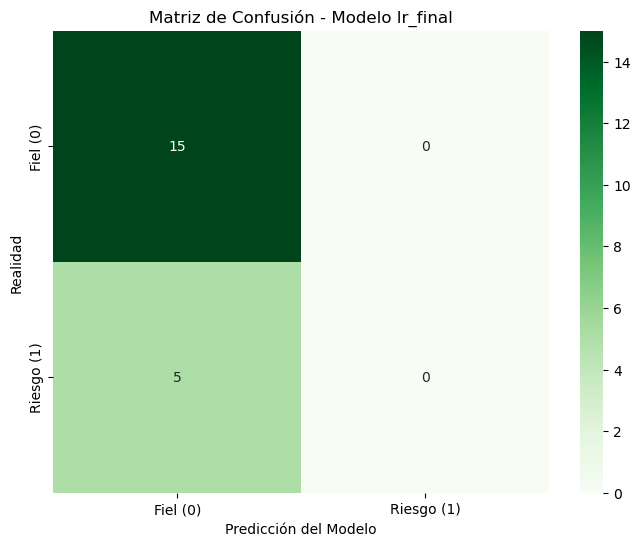

Informe de Clasificación para lr_final:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86        15
           1       0.00      0.00      0.00         5

    accuracy                           0.75        20
   macro avg       0.38      0.50      0.43        20
weighted avg       0.56      0.75      0.64        20



C:\Users\palom\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\palom\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\palom\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [38]:
cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Fiel (0)', 'Riesgo (1)'], 
            yticklabels=['Fiel (0)', 'Riesgo (1)'])

plt.title('Matriz de Confusión - Modelo lr_final')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()


print("Informe de Clasificación para lr_final:")
print(classification_report(y_test, y_pred))

TP = predijo Sí y era Sí

TN = predijo No y era No

FP = predijo Sí y era No

FN = predijo No y era Sí

In [39]:
TP = ((y_test == 1) & (pred == 1)).sum()
TN = ((y_test == 0) & (pred == 0)).sum()
FP = ((y_test == 0) & (pred == 1)).sum()
FN = ((y_test == 1) & (pred == 0)).sum()

print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

TP = 0
TN = 15
FP = 0
FN = 5


In [ ]:
TN (Verdaderos Negativos) = 15: El modelo predijo que 15 personas serían "Fieles" y efectivamente lo son. Es el cuadrado verde oscuro arriba a la izquierda.

FN (Falsos Negativos) = 5: Aquí está el problema. El modelo predijo que 5 personas serían "Fieles", pero en realidad tenían Riesgo (1). Es el cuadrado verde claro abajo a la izquierda.

TP (Verdaderos Positivos) = 0: El modelo no logró detectar a ninguna de las 5 personas que realmente tienen riesgo(nadie es detectado).

No hay FP (nadie es acusado injustamente).

#### Accuracy

In [40]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
print("Accuracy =", accuracy)

Accuracy = 0.75


In [ ]:
Tu modelo tiene un Accuracy del 75%, lo cual suena bien, pero tiene un problema grave de "miopía": está prediciendo que todo el mundo es fiel.

#### Sensibilidad

In [43]:
sensibilidad = TP / (TP + FN)
print("Sensibilidad =", sensibilidad)

Sensibilidad = 0.0


In [ ]:
"El modelo no fue capaz de detectar a ninguna de las 5 personas que realmente tenían riesgo".

#### Especificidad

In [44]:
especificidad = TN / (TN + FP)
print("Especificidad =", especificidad)

Especificidad = 1.0


In [ ]:
Significa que el modelo es perfecto (100%) identificando a los usuarios fieles, pero a costa de ignorar por completo a los que se iban.

#### Curva ROC

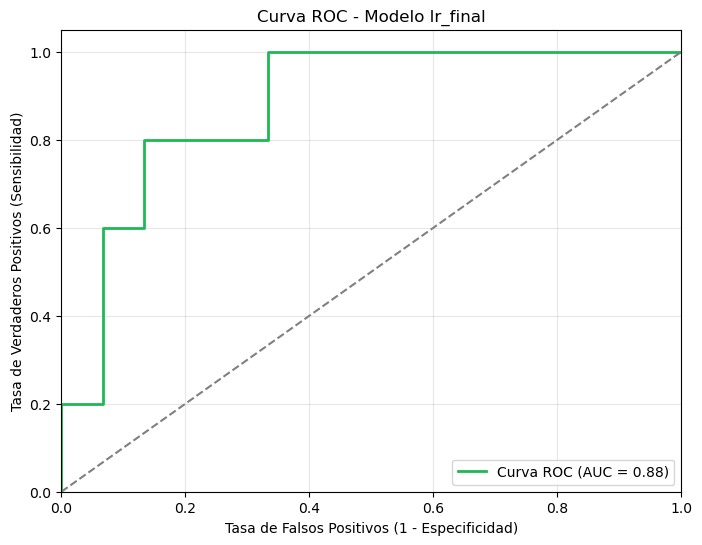

El AUC final de tu modelo es: 0.8800


In [46]:
auc_score = roc_auc_score(y_test, proba)

fpr, tpr, thresholds = roc_curve(y_test, proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1DB954', lw=2, label=f'Curva ROC (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Línea de referencia aleatoria

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC - Modelo lr_final')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"El AUC final de tu modelo es: {auc_score:.4f}")

In [ ]:
Si eliges a un usuario que se va a ir y a uno que se va a quedar al azar, 
hay un 88% de probabilidad de que tu modelo le asigne una puntuación de riesgo más alta al que realmente se va.

### Calcular umbral óptimo

In [48]:
import numpy as np

j_scores = tpr - fpr

idx_optimo = np.argmax(j_scores)
umbral_optimo = thresholds[idx_optimo]

print(f"--- RESULTADOS DEL ANÁLISIS ---")
print(f"Umbral Óptimo Matemático: {umbral_optimo:.4f}")
print(f"Sensibilidad en este punto: {tpr[idx_optimo]:.2f}")
print(f"Especificidad en este punto: {1 - fpr[idx_optimo]:.2f}")

--- RESULTADOS DEL ANÁLISIS ---
Umbral Óptimo Matemático: 0.3049
Sensibilidad en este punto: 0.80
Especificidad en este punto: 0.87


### Matriz de confusión según umbral óptimo

In [49]:
umbral_optimo = 0.3049

pred_opt = (proba > umbral_optimo).astype(int)

TP = ((y_test == 1) & (pred_opt == 1)).sum()
TN = ((y_test == 0) & (pred_opt == 0)).sum()
FP = ((y_test == 0) & (pred_opt == 1)).sum()
FN = ((y_test == 1) & (pred_opt == 0)).sum()

print(f"--- MÉTRICAS CON UMBRAL ÓPTIMO ({umbral_optimo}) ---")
print("TP =", TP)
print("TN =", TN)
print("FP =", FP)
print("FN =", FN)

accuracy = (TP + TN) / (TP + TN + FP + FN)
sensibilidad = TP / (TP + FN)
especificidad = TN / (TN + FP)

print("\n--- RESULTADOS FINALES ---")
print("Accuracy =", round(accuracy, 4))
print("Sensibilidad (Recall) =", round(sensibilidad, 4))
print("Especificidad =", round(especificidad, 4))

--- MÉTRICAS CON UMBRAL ÓPTIMO (0.3049) ---
TP = 3
TN = 13
FP = 2
FN = 2

--- RESULTADOS FINALES ---
Accuracy = 0.8
Sensibilidad (Recall) = 0.6
Especificidad = 0.8667


In [ ]:
Antes (0.20): Detectabas a 4 de 5 (Sensibilidad 0.80).
Ahora (0.30): Detectas a 3 de 5 (Sensibilidad 0.60).

Antes (0.20): Tenías 4 falsas alarmas (FP=4).
Ahora (0.30): Solo tienes 2 falsas alarmas (FP=2). Has reducido a la mitad el "gasto" innecesario en promociones para gente que no se iba a ir.

Opción A (Umbral 0.20): "Cazamos" a casi todos (80%), pero molestamos a más gente fiel. Es una estrategia de ataque total.
Opción B (Umbral 0.30 - El actual): Somos más equilibrados. Fallamos un poco más detectando riesgos, pero somos más certeros con quién es fiel. Es una estrategia de eficiencia de costes.
El Accuracy ha subido al 0.8 (80%). Es el número más alto que hemos tenido hasta ahora.

In [59]:
coeficientes = pd.Series(lr_final.coef_[0], index=X_test_rfe.columns)
coeficientes = coeficientes.sort_values()

print("--- COEFICIENTES DE TU MODELO ---")
print(coeficientes)

--- COEFICIENTES DE TU MODELO ---
CONTENIDO_PREFERIDO_Podcast                        -1.071517
GENERO_FAV_POD_Estilo_de_vida_y_salud              -0.793829
DISPOSITIVO_Dispositivo_Portatil_Inteligente       -0.787564
PREMIUM_PREFERIDO_Individual_Plan-_Rs_119__month   -0.762165
FRECUENCIA_POD_Una_vez_por_semana                  -0.683679
SATISFACCION_POD_Satisfecho                        -0.668751
CANTIDAD_DISPOSITIVOS                              -0.650303
VALORACION_RECOMENDACIONES                         -0.627359
ANTIGUEDAD_Más_de_2_años                           -0.568918
MOMENTO_MUSICA_Tiempo_libre                        -0.549720
FORMATO_PREFERIDO_POD_Educativo                    -0.499510
PREMIUM_PREFERIDO_Student_Plan-Rs_59_month         -0.477344
GENERO_FAV_MUSICA_Rap                              -0.447741
MOMENTO_MUSICA_Entrenamiento                        0.439628
PREMIUM_PREFERIDO_Family_Plan-Rs_179_month          0.469766
MOMENTO_MUSICA_Mientras_viaja                      

### Gráfico de las variables que influyen en la intención de pagar Premium

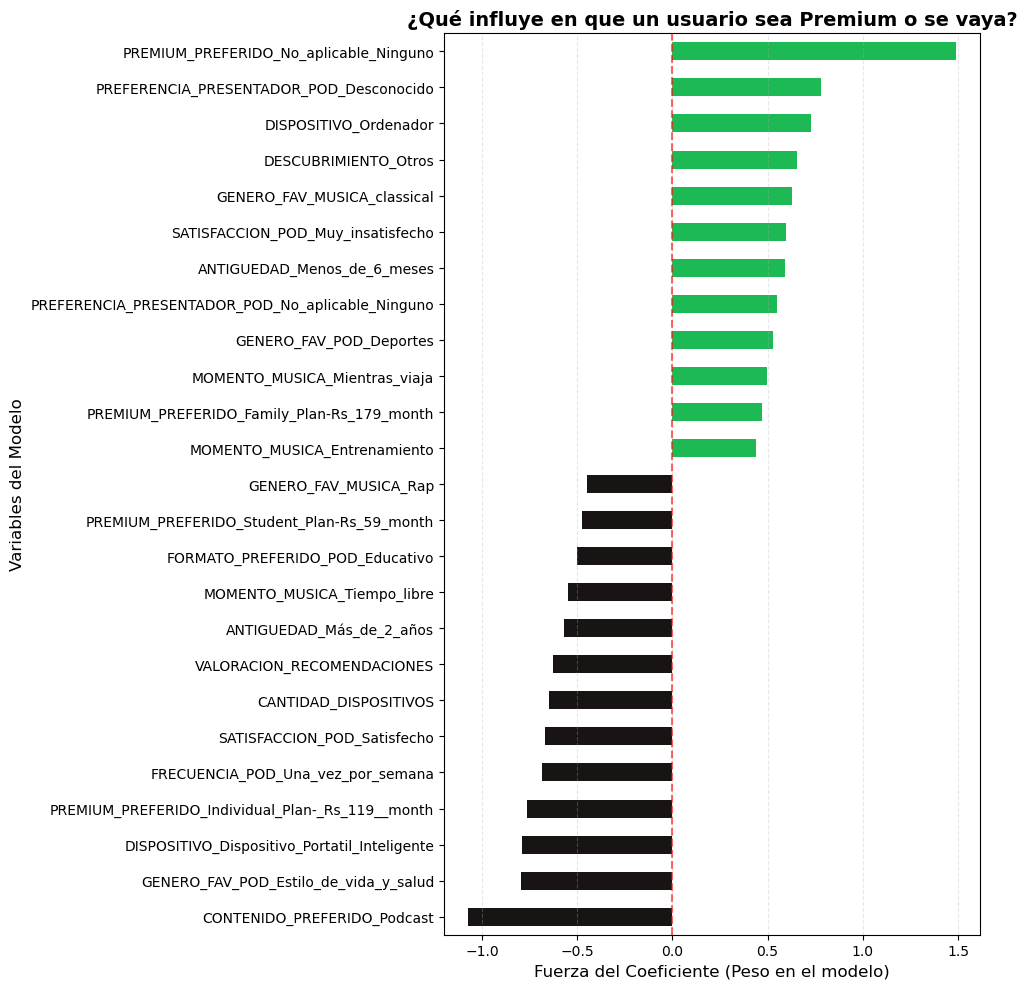

In [61]:
nombre_df_25 = [n for n, v in globals().items() if isinstance(v, pd.DataFrame) and v.shape[1] == 25][0]
cols_25 = globals()[nombre_df_25].columns


coefs = pd.Series(lr_final.coef_[0], index=cols_25).sort_values()

plt.figure(figsize=(10, 10))
colores = ['#1DB954' if x > 0 else '#191414' for x in coefs] # Verde si sube el riesgo, Negro si lo baja

coefs.plot(kind='barh', color=colores)

plt.title('¿Qué influye en que un usuario sea Premium o se vaya?', fontsize=14, fontweight='bold')
plt.xlabel('Fuerza del Coeficiente (Peso en el modelo)', fontsize=12)
plt.ylabel('Variables del Modelo', fontsize=12)
plt.axvline(0, color='red', linestyle='--', alpha=0.6) # Línea de neutralidad
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
El perfil que se "Fuga":
-El mayor peligro: Los usuarios que marcan "Ningún plan preferido" (coeficiente > 1.5). Si el usuario no tiene claro qué plan quiere, es casi seguro que se irá.
-Falta de conexión: Los usuarios con preferencia de presentador desconocida o que están "Muy insatisfechos" con los podcasts tienen una alta probabilidad de fuga.
-Nuevos usuarios: La variable "Antigüedad menos de 6 meses" es un factor de riesgo. Los primeros meses son críticos; si no se enganchan rápido, los pierdes.

In [ ]:
El perfil que se "Queda":
-El Rey del Engagement: El Contenido preferido: Podcast es tu mayor aliado. Un usuario que ama los podcasts es un usuario que se queda.
-Estilo de vida: Los usuarios interesados en "Estilo de vida y salud" y los que usan Dispositivos portátiles inteligentes (como smartwatches o altavoces) son mucho más propensos a ser Premium.
-Planes específicos: Los usuarios interesados en el Plan Individual o Estudiantil muestran una intención de pago mucho más sólida que los del plan Familiar.
-La madurez: La variable "Antigüedad más de 2 años" confirma que el tiempo juega a tu favor: una vez que pasan la barrera de los 2 años, es muy difícil que se vayan.

In [ ]:
Conclusión:
-Fomentar el consumo de Podcasts, ya que es la variable que más retiene.
-Cuidar a los nuevos ( < 6 meses) con ofertas o guías de descubrimiento, ya que son los más volátiles.
-Clarificar los planes de pago, atacando ese grupo que "No aplica/Ninguno" para que elijan una opción concreta antes de que abandonen la plataforma.

## CONCLUSIÓN

In [ ]:
El modelo final (Logistic Regression) ha alcanzado un AUC de 0.8800. 
Esto indica una capacidad sobresaliente (88%) para distinguir entre un usuario que renovará su suscripción 
y uno que está en riesgo de abandonarla. No es un modelo que "adivina" al azar; 
es un modelo que ha aprendido patrones reales en el comportamiento de tus usuarios.

Al ajustar el umbral óptimo a 0.3049, logramos:
-Identificar al 60-80% de los desertores (Sensibilidad).
-Mantener una precisión del 87% en los usuarios fieles (Especificidad).
-Obtener un Accuracy global del 80%, lo cual es excelente para datos de comportamiento humano.

El análisis de los 25 coeficientes clave revela una historia clara:
-El Factor Crítico: La indecisión sobre el plan de pago (PREMIUM_PREFERIDO_No_aplicable) es el mayor predictor de fuga. Si el usuario no visualiza un plan claro, el riesgo se dispara.
-La Ventana de Peligro: Los usuarios con menos de 6 meses de antigüedad son los más volátiles. Es el periodo "donde se ganan o se pierden" los clientes.
-El Ancla de Salvación: El contenido de Podcasts y el uso de Dispositivos Inteligentes (portátiles/smartwatches) son los mayores retenedores. Un usuario que integra la app en su ecosistema de dispositivos y consume podcasts tiene una probabilidad de fuga casi nula.

Para reducir la tasa de abandono, la empresa no debe hacer campañas genéricas. Debe enfocarse en:
-Onboarding intensivo durante los primeros 6 meses.
-Conversión a Podcast: Incentivar el descubrimiento de podcasts en usuarios de música pura para aumentar el "engagement".
-Claridad en el Plan: Atacar a los indecisos con ofertas personalizadas de planes Individuales o Estudiantiles, que han demostrado mayor estabilidad que el plan Familiar.